In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ncr_ride_bookings.csv")
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
df.dtypes

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

In [4]:
print(f"original shape of data: {df.shape}")

original shape of data: (150000, 21)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [6]:
# checking for null values
df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [7]:
# filling columns with 0 and 1
col = ["Cancelled Rides by Driver","Incomplete Rides","Cancelled Rides by Customer"]
for i in col:
    df[i] = df[i].notna().astype(int)

In [8]:
df["Reason for cancelling by Customer"] = df["Reason for cancelling by Customer"].fillna("Not Applicable")
df["Driver Cancellation Reason"] = df["Driver Cancellation Reason"].fillna("Not known")
df["Incomplete Rides Reason"] = df["Incomplete Rides Reason"].fillna("Not Known")

In [9]:
pd.crosstab(df["Booking Status"], df["Ride Distance"].isna())

Ride Distance,False,True
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,93000,0
Incomplete,9000,0
No Driver Found,0,10500


In [10]:
pd.crosstab(df["Booking Status"], df["Booking Value"].isna())

Booking Value,False,True
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,93000,0
Incomplete,9000,0
No Driver Found,0,10500


In [11]:
completed = df[df["Booking Status"] == "Completed"]
avg_fare = completed["Booking Value"].mean()
avg_distance = completed["Ride Distance"].mean()

In [12]:
# checking Payment Method is null or not
df["Payment_Method_Null"] = df["Payment Method"].isna()
# Booking Status vs Payment Method Null
pd.crosstab(df["Booking Status"], df["Payment_Method_Null"])

Payment_Method_Null,False,True
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,93000,0
Incomplete,9000,0
No Driver Found,0,10500


In [13]:
# dropping column which created only for analysis
df.drop(columns=["Payment_Method_Null"],inplace = True)

In [14]:
null_payment = df[df["Payment Method"].isna()]
null_payment["Booking Status"].value_counts(normalize=True) * 100

Booking Status
Cancelled by Driver      56.250
No Driver Found          21.875
Cancelled by Customer    21.875
Name: proportion, dtype: float64

In [15]:
df["Payment Method"] = df["Payment Method"].fillna("Not Applicable")

In [16]:
pd.crosstab(df["Booking Status"],df["Driver Ratings"].isna())

Driver Ratings,False,True
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,93000,0
Incomplete,0,9000
No Driver Found,0,10500


In [17]:
pd.crosstab(df["Booking Status"],df["Customer Rating"].isna())

Customer Rating,False,True
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,93000,0
Incomplete,0,9000
No Driver Found,0,10500


In [18]:
pd.crosstab(df["Booking Status"],df["Avg VTAT"].isna())

Avg VTAT,False,True
Booking Status,,
Cancelled by Customer,10500,0
Cancelled by Driver,27000,0
Completed,93000,0
Incomplete,9000,0
No Driver Found,0,10500


In [19]:
df.isna().sum()

Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Avg VTAT                             10500
Avg CTAT                             48000
Cancelled Rides by Customer              0
Reason for cancelling by Customer        0
Cancelled Rides by Driver                0
Driver Cancellation Reason               0
Incomplete Rides                         0
Incomplete Rides Reason                  0
Booking Value                        48000
Ride Distance                        48000
Driver Ratings                       57000
Customer Rating                      57000
Payment Method                           0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df["Date"] = pd.to_datetime(df["Date"])

In [22]:
df["Time"] = pd.to_datetime(df["Time"])

C:\Users\nikit\AppData\Local\Temp\ipykernel_17988\3349344153.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"])


In [23]:
df["Booking ID"] = df["Booking ID"].str.strip('"')
df["Customer ID"] = df["Customer ID"].str.strip('"')

In [24]:
df["Hour"] = df["Time"].dt.hour
df["DayOfWeek"] = df["Date"].dt.day_name()
df["IsWeekend"] = df["Date"].dt.dayofweek >= 5

In [25]:
df.to_csv("ncr_ride_bookings_cleaned.csv", index=False)

EDA

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\nikit\AppData\Local\Temp\ipykernel_17988\935190460.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=booking_status.values,y=booking_status.index,palette='viridis')


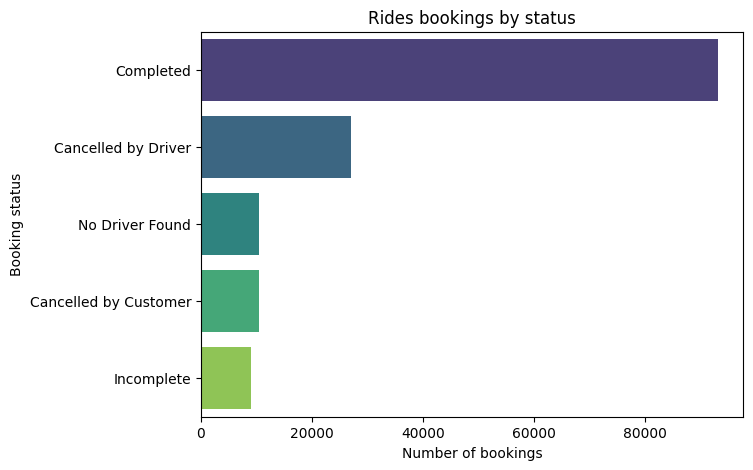

In [27]:
# checking status of booking rides
booking_status = df["Booking Status"].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(x=booking_status.values,y=booking_status.index,palette='viridis')
plt.title("Rides bookings by status")
plt.xlabel("Number of bookings")
plt.ylabel("Booking status")
plt.show()

C:\Users\nikit\AppData\Local\Temp\ipykernel_17988\772246442.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_cancel.values,y=reason_cancel.index,palette='magma')


Text(0, 0.5, 'Reasons')

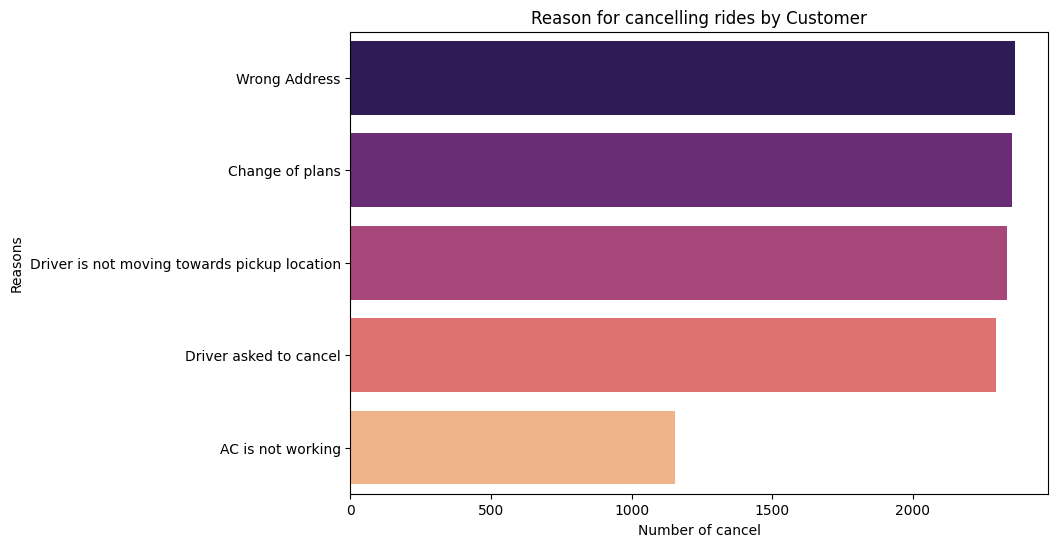

In [28]:
# Reasons for cancelling rides by customer
cancelled_by_customer = df[df["Cancelled Rides by Customer"] == 1]
reason_cancel  = cancelled_by_customer["Reason for cancelling by Customer"].value_counts()
plt.figure(figsize=(9,6))
sns.barplot(x=reason_cancel.values,y=reason_cancel.index,palette='magma')
plt.title("Reason for cancelling rides by Customer")
plt.xlabel("Number of cancel")
plt.ylabel("Reasons")

C:\Users\nikit\AppData\Local\Temp\ipykernel_17988\550345067.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_cancel.values,y=reason_cancel.index,palette='magma')


Text(0, 0.5, 'Reasons')

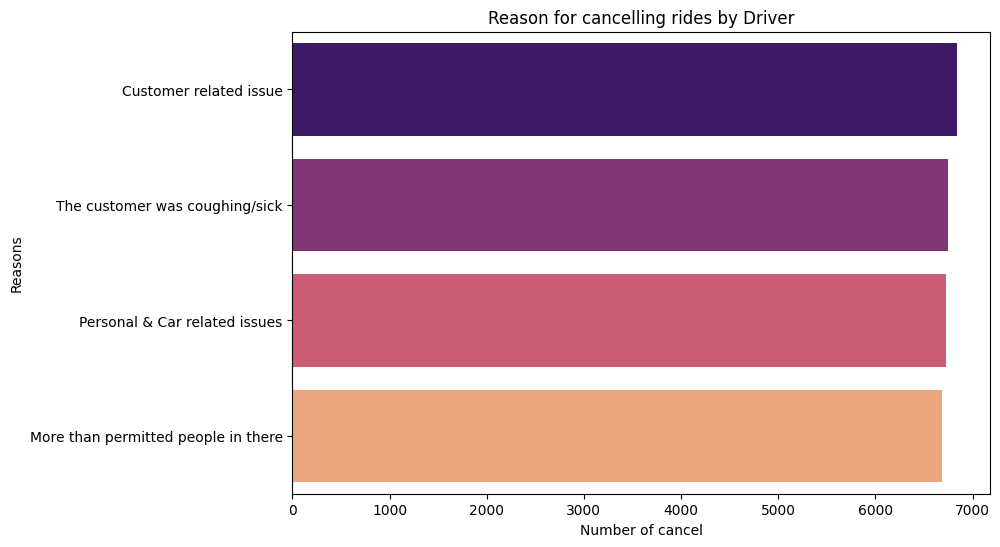

In [ ]:
# Reasons for cancelling rides by Driver
cancelled_by_customer = df[df["Cancelled Rides by Driver"] == 1]
reason_cancel  = cancelled_by_customer["Driver Cancellation Reason"].value_counts()
plt.figure(figsize=(9,6))
sns.barplot(x=reason_cancel.values,y=reason_cancel.index,palette='magma')
plt.title("Reason for cancelling rides by Driver")
plt.xlabel("Number of cancel")
plt.ylabel("Reasons")

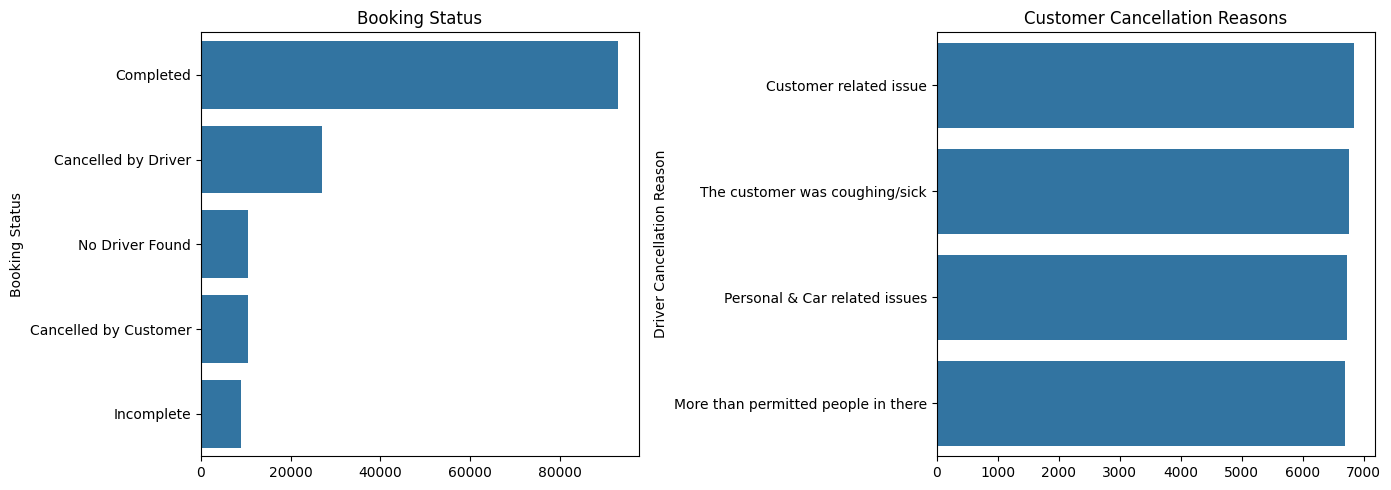

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x=booking_status.values, y=booking_status.index, ax=axes[0])
axes[0].set_title("Booking Status")

sns.barplot(x=reason_cancel.values, y=reason_cancel.index, ax=axes[1])
axes[1].set_title("Customer Cancellation Reasons")
plt.tight_layout()
plt.show()

C:\Users\nikit\AppData\Local\Temp\ipykernel_17988\875526022.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=incomplete_reason.values,y=incomplete_reason.index,palette='magma')


<Axes: ylabel='Incomplete Rides Reason'>

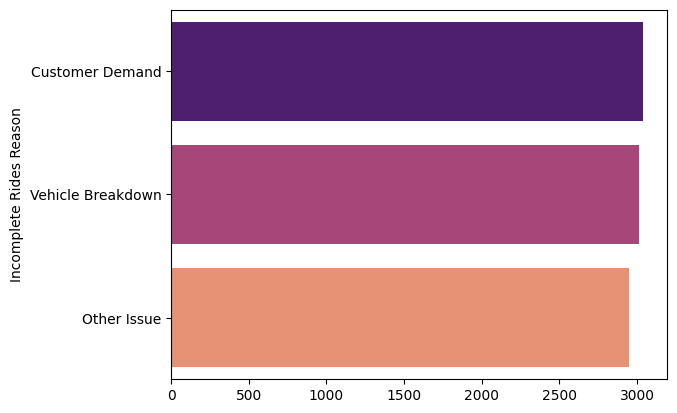

In [31]:
# Reasons why rides getting incompleted?
incomplate_rides = df[df['Incomplete Rides']==1]
incomplete_reason = incomplate_rides['Incomplete Rides Reason'].value_counts()
sns.barplot(x=incomplete_reason.values,y=incomplete_reason.index,palette='magma')

C:\Users\nikit\AppData\Local\Temp\ipykernel_17988\2586693808.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10['cancellation_rate'],y=top10.index,palette="rocket")


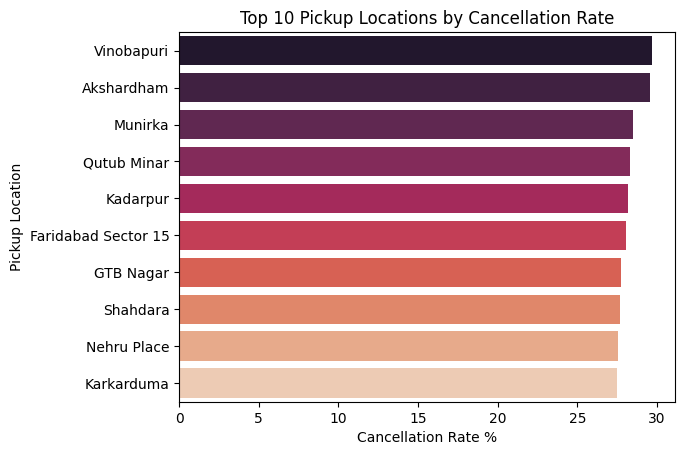

In [32]:
# which pick up location have highest cancellation rides? 
df['cancel_rides'] = df["Booking Status"].isin(['Cancelled by Customer','Cancelled by Driver'])

grp = df.groupby('Pickup Location').agg(
    total_bookings = ("Booking Status",'count'),
    cancelled = ("cancel_rides","sum")
)
grp['cancellation_rate'] = (grp['cancelled'] / grp['total_bookings'] * 100).round(2)
grp = grp.sort_values('cancellation_rate', ascending=False)

top10 = grp.head(10)
sns.barplot(x=top10['cancellation_rate'],y=top10.index,palette="rocket")
plt.title("Top 10 Pickup Locations by Cancellation Rate")
plt.xlabel("Cancellation Rate %")
plt.ylabel("Pickup Location")
plt.show()

In [ ]:
# Checking : are demands increase during workday or hour/day?
daily_counts = df.groupby(df["Date"].dt.date).size()  
daily_counts = daily_counts.reset_index()
daily_counts.columns = ["Date", "Bookings"]
daily_counts["Date"] = pd.to_datetime(daily_counts["Date"])
daily_counts["IsWeekend"] = daily_counts["Date"].dt.dayofweek >= 5

avg_by_day = daily_counts.assign(DayOfWeek=daily_counts["Date"].dt.day_name())
avg_by_day = avg_by_day.groupby("DayOfWeek")["Bookings"].mean()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
avg_by_day = avg_by_day.reindex(order)

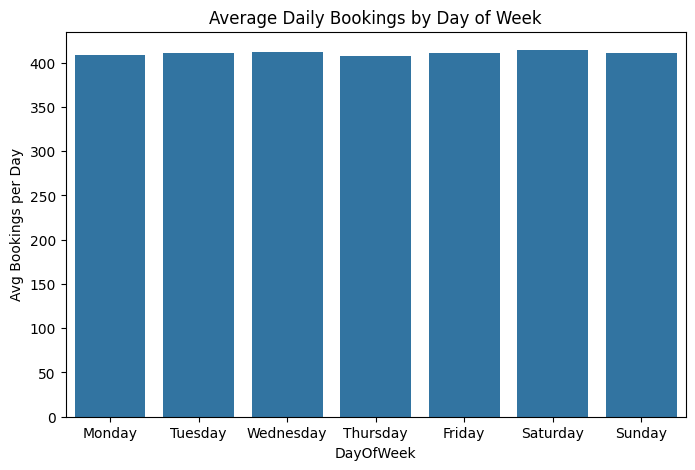

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(x=avg_by_day.index, y=avg_by_day.values)
plt.title("Average Daily Bookings by Day of Week")
plt.ylabel("Avg Bookings per Day")
plt.show()

In [35]:
# checking Do ratings correlate with anything (vehicle type, distance, fare)?
completed = df[df["Booking Status"] == "Completed"]
completed[['Driver Ratings','Customer Rating','Ride Distance','Booking Value']].corr()

,Driver Ratings,Customer Rating,Ride Distance,Booking Value
Driver Ratings,1.000000,-0.001010,-0.001875,-0.000249
Customer Rating,-0.001010,1.000000,0.004514,-0.000287
Ride Distance,-0.001875,0.004514,1.000000,0.005668
Booking Value,-0.000249,-0.000287,0.005668,1.000000


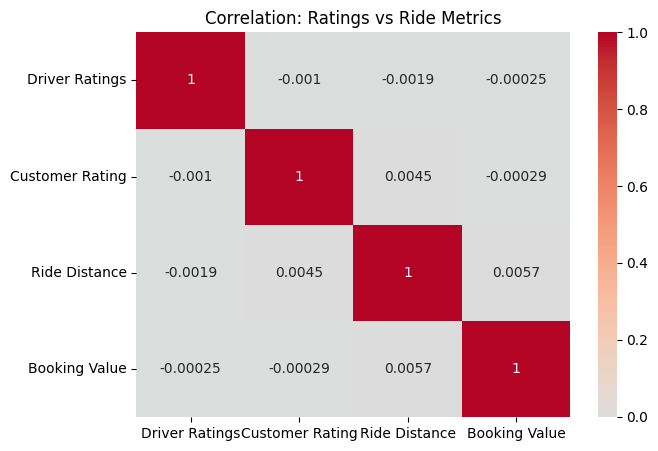

In [36]:
plt.figure(figsize=(7,5))
sns.heatmap(completed[['Driver Ratings','Customer Rating','Ride Distance','Booking Value']]
            .corr(),annot=True,cmap="coolwarm",center=0)
plt.title("Correlation: Ratings vs Ride Metrics")
plt.show()

In [37]:
# checking by vehicle type (categorical, not numeric) so use group by means instead of correlation
completed.groupby("Vehicle Type")["Driver Ratings"].mean().sort_values(ascending=False)

Vehicle Type
Uber XL          4.238340
Premier Sedan    4.234865
Auto             4.232369
Go Sedan         4.231812
Bike             4.230056
Go Mini          4.227694
eBike            4.225614
Name: Driver Ratings, dtype: float64

C:\Users\nikit\AppData\Local\Temp\ipykernel_17988\1950957931.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_ndf['rate'], y=top10_ndf.index, palette="mako")


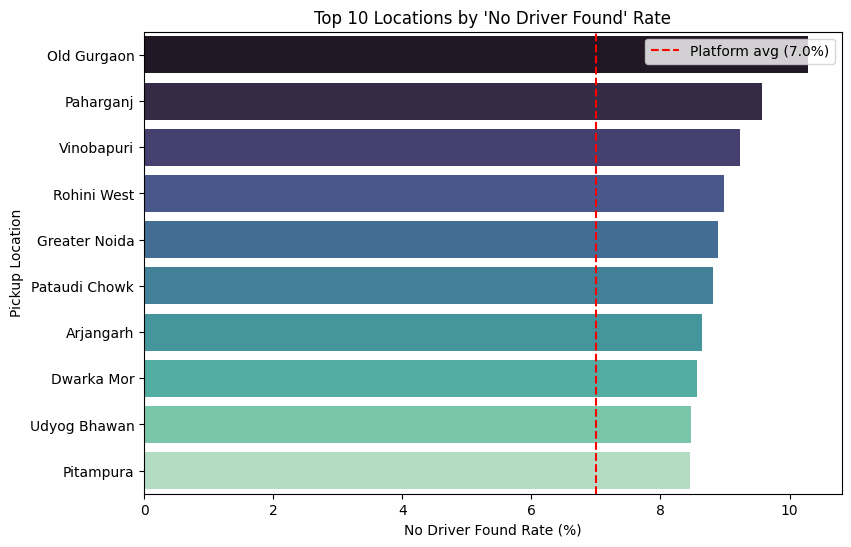

In [ ]:
# Is there a pattern in "No Driver Found" — specific times, locations, vehicle types?
df['Is_NDF'] = df['Booking Status'] == 'No Driver Found'

# Group by Pickup Location
by_loc = df.groupby('Pickup Location').agg(
    total=('Booking Status', 'count'),
    ndf=('Is_NDF', 'sum')
)
by_loc['rate'] = (by_loc['ndf'] / by_loc['total'] * 100).round(2)
by_loc = by_loc[by_loc['total'] >= 100]

top10_ndf = by_loc.sort_values('rate', ascending=False).head(10)

plt.figure(figsize=(9,6))
sns.barplot(x=top10_ndf['rate'], y=top10_ndf.index, palette="mako")
plt.axvline(7.0, color='red', linestyle='--', label='Platform avg (7.0%)')
plt.title("Top 10 Locations by 'No Driver Found' Rate")
plt.xlabel("No Driver Found Rate (%)")
plt.legend()
plt.show()

In [40]:
hour_demand = df.groupby(df["Time"].dt.hour).size()
n_days = df['Date'].dt.date.nunique()
hourly_demand_avg = hour_demand / n_days

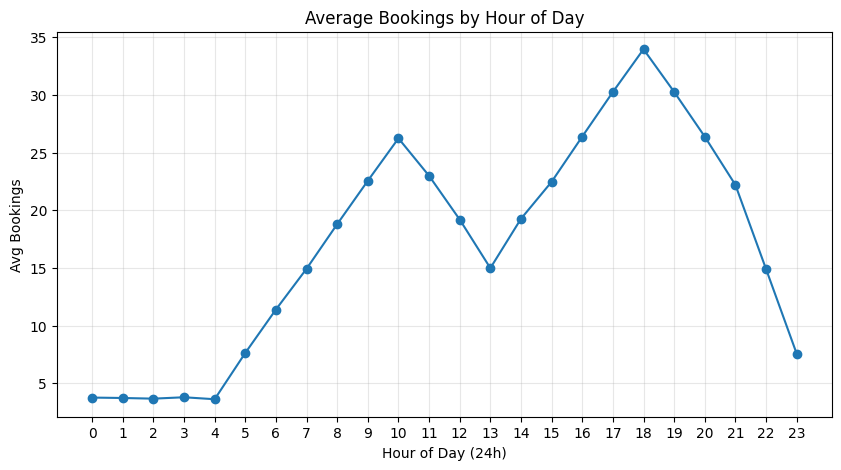

In [41]:
plt.figure(figsize=(10,5))
hourly_demand_avg.plot(kind='line', marker='o')
plt.title("Average Bookings by Hour of Day")
plt.xlabel("Hour of Day (24h)")
plt.ylabel("Avg Bookings")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.show()